# Phase 2: Better Clustering with HDBSCAN

KMeans forces you to pick `k`, treats every cluster as an equally-sized sphere, and needs a hand-tuned standard-deviation threshold to call anything an outlier. On datasets with uneven category sizes that produces noisy gap signals.

**HDBSCAN fixes all three issues:**
- **Density-based:** it finds clusters of varying size and shape instead of fitting spheres.
- **Automatic `k`:** no silhouette loop, no parameter to guess.
- **Native outliers:** low-density points get `cluster_id = -1`. That label *is* the outlier signal.

This notebook walks through the four changes the plugin picked up in Phase 2:

| Sub-phase | Change |
|-----------|--------|
| 2.1 | HDBSCAN replaces KMeans (cosine metric, `eom` selection, `min_cluster_size=3`). |
| 2.2 | Noise points stored with `cluster_id=-1` + `is_outlier=True`; HDBSCAN's `probabilities_` vector stored as `cluster_confidence`. |
| 2.3 | KMeans kept as a fallback: `num_clusters=0` → HDBSCAN, `num_clusters>0` → KMeans with that exact `k`. |
| 2.4 | UMAP still runs after clustering; noise points render as gray hollow markers, visually separated from clustered points. |

The plugin's production code lives in `__init__.py::run_clustering`. This notebook reimplements the essentials inline against synthetic data so it stays self-contained.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import normalize
import hdbscan
import umap

# Same constants the plugin uses in __init__.py
HDBSCAN_MIN_CLUSTER_SIZE = 3
HDBSCAN_METRIC = "cosine"
HDBSCAN_CLUSTER_SELECTION_METHOD = "eom"
KMEANS_RANDOM_STATE = 42
KMEANS_N_INIT = 10
OUTLIER_STD_FACTOR = 2.0
UMAP_N_COMPONENTS = 2
UMAP_METRIC = "cosine"
UMAP_MIN_DIST = 0.1
UMAP_RANDOM_STATE = 42

## 2. Synthetic embeddings

To keep the demo reproducible we build 4 tight clusters of 12 points each plus 8 random scatter points on the unit sphere (512-d, matching Marengo). The random points *should* end up as HDBSCAN noise.

In [2]:
rng = np.random.default_rng(42)
D = 512

def make_cluster(center, n, spread=0.03):
    center = center / np.linalg.norm(center)
    pts = center + rng.normal(0, spread, size=(n, D))
    return pts / np.linalg.norm(pts, axis=1, keepdims=True)

centers = [rng.standard_normal(D) for _ in range(4)]
centers = [c / np.linalg.norm(c) for c in centers]

X = np.vstack([make_cluster(c, 12) for c in centers] + [rng.standard_normal((8, D))])
embeddings_norm = X / np.linalg.norm(X, axis=1, keepdims=True)

print(f"shape: {embeddings_norm.shape}")
print(f"  4 clusters × 12 = 48 structured points")
print(f"  + 8 random scatter points")
print(f"  = {embeddings_norm.shape[0]} total")

shape: (56, 512)
  4 clusters × 12 = 48 structured points
  + 8 random scatter points
  = 56 total


## 3. HDBSCAN clustering

Two non-obvious choices:

- **`metric="cosine"`** matches the Marengo embedding space. HDBSCAN's default BallTree backend rejects cosine, so we pass **`algorithm="generic"`** to route through `sklearn.pairwise_distances`.
- **`cluster_selection_method="eom"`** (Excess of Mass) is better than the default `"leaf"` for this use case: it prefers fewer, larger clusters, which is what you want when category sizes are uneven.

In [3]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    metric=HDBSCAN_METRIC,
    cluster_selection_method=HDBSCAN_CLUSTER_SELECTION_METHOD,
    algorithm="generic",
)
labels_hdb = clusterer.fit_predict(embeddings_norm)
probs_hdb = clusterer.probabilities_

unique_non_noise = np.sort(np.unique(labels_hdb[labels_hdb >= 0]))
n_clusters = len(unique_non_noise)
n_noise = int((labels_hdb == -1).sum())

print(f"n_clusters (non-noise): {n_clusters}")
print(f"n_noise:                {n_noise}")
print(f"unique labels:          {sorted(set(labels_hdb.tolist()))}")
print(f"\nFirst 10 labels: {labels_hdb[:10]}")
print(f"Last 10 labels:  {labels_hdb[-10:]}  ← the 8 random scatter points sit here")

n_clusters (non-noise): 4
n_noise:                8
unique labels:          [-1, 0, 1, 2, 3]

First 10 labels: [0 0 0 0 0 0 0 0 0 0]
Last 10 labels:  [ 2  2 -1 -1 -1 -1 -1 -1 -1 -1]  ← the 8 random scatter points sit here


## 4. `cluster_confidence` from `probabilities_`

HDBSCAN exposes a membership-strength vector in `[0, 1]`. The plugin writes this to every sample as `cluster_confidence`:

- **Noise points** (`cluster_id = -1`) get `probability = 0` by definition — HDBSCAN is certain they don't belong anywhere.
- **Clustered points** near the cluster core get values close to 1.
- **Points near cluster boundaries** get low-but-nonzero values — a secondary, softer gap signal than the hard `-1` label.

In [4]:
print("Confidence distribution:")
if n_noise:
    noise_conf = probs_hdb[labels_hdb == -1]
    print(f"  noise    (n={n_noise}): "
          f"min={noise_conf.min():.3f}  mean={noise_conf.mean():.3f}  max={noise_conf.max():.3f}")
if n_clusters:
    clust_conf = probs_hdb[labels_hdb >= 0]
    print(f"  clustered (n={(labels_hdb >= 0).sum()}): "
          f"min={clust_conf.min():.3f}  mean={clust_conf.mean():.3f}  max={clust_conf.max():.3f}")

# The 5 lowest-confidence assignments — these sit near cluster boundaries
# and are the "secondary gap signal" the plugin can surface later.
low_order = np.argsort(probs_hdb)
print("\n5 lowest-confidence samples (idx, label, probability):")
for idx in low_order[:5]:
    print(f"  idx={int(idx):3d}  label={int(labels_hdb[idx]):3d}  prob={float(probs_hdb[idx]):.3f}")

Confidence distribution:
  noise    (n=8): min=0.000  mean=0.000  max=0.000
  clustered (n=48): min=0.916  mean=0.972  max=1.000

5 lowest-confidence samples (idx, label, probability):
  idx= 48  label= -1  prob=0.000
  idx= 49  label= -1  prob=0.000
  idx= 50  label= -1  prob=0.000
  idx= 51  label= -1  prob=0.000
  idx= 52  label= -1  prob=0.000


## 5. KMeans fallback (`num_clusters > 0`)

HDBSCAN is a strict improvement for most cases, but there are times users know the exact partition they want: a known category count, a small dataset, or simply a fixed baseline. The plugin keeps KMeans reachable via the `num_clusters` operator input — set it to any positive integer and the clustering stage branches to KMeans with that `k`.

Two differences vs HDBSCAN in this path:

1. **No `-1` label.** KMeans assigns every point to some centroid.
2. **Distance-threshold outliers.** The classic heuristic: `distance_to_centroid > mean + OUTLIER_STD_FACTOR * std` — configurable via the `outlier_threshold` operator input.

In both paths `cluster_confidence` is populated so downstream code can read it uniformly; under KMeans it's set to `1.0` (KMeans has no native membership score).

In [5]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=KMEANS_RANDOM_STATE, n_init=KMEANS_N_INIT)
labels_km = kmeans.fit_predict(embeddings_norm)
centroids_norm = normalize(kmeans.cluster_centers_, norm="l2")

# Per-sample cosine distance to assigned centroid
distances_km = np.array([
    cosine_distances(
        embeddings_norm[i:i + 1],
        centroids_norm[labels_km[i]:labels_km[i] + 1],
    )[0, 0]
    for i in range(len(embeddings_norm))
])

mean_d, std_d = distances_km.mean(), distances_km.std()
threshold = mean_d + OUTLIER_STD_FACTOR * std_d
is_outlier_km = distances_km > threshold

print(f"KMeans k={k}:")
print(f"  every point assigned, unique labels: {sorted(set(labels_km.tolist()))}")
print(f"  cosine distance: mean={mean_d:.3f}  std={std_d:.3f}")
print(f"  outlier threshold (mean + {OUTLIER_STD_FACTOR}·std): {threshold:.3f}")
print(f"  outliers flagged: {int(is_outlier_km.sum())}")

KMeans k=4:
  every point assigned, unique labels: [0, 1, 2, 3]
  cosine distance: mean=0.267  std=0.253
  outlier threshold (mean + 2.0·std): 0.774
  outliers flagged: 8


## 6. UMAP after clustering

UMAP runs **after** the clustering stage in both paths. It's a separate concern — it's for visualization and coverage-grid estimation, not for deciding what's noise. We feed it the same L2-normalized embeddings and ask for 2D cosine-metric coords.

In [6]:
reducer = umap.UMAP(
    n_components=UMAP_N_COMPONENTS,
    metric=UMAP_METRIC,
    n_neighbors=min(5, embeddings_norm.shape[0] - 1),
    min_dist=UMAP_MIN_DIST,
    random_state=UMAP_RANDOM_STATE,
)
coords = reducer.fit_transform(embeddings_norm)
print(f"UMAP 2D shape: {coords.shape}")
print(f"x-range: [{coords[:, 0].min():.2f}, {coords[:, 0].max():.2f}]")
print(f"y-range: [{coords[:, 1].min():.2f}, {coords[:, 1].max():.2f}]")

/Users/surabhigade/Desktop/video-content-gap-analyzer/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D shape: (56, 2)
x-range: [-12.93, 13.74]
y-range: [-4.86, 12.51]


## 7. Visualizing noise distinctly

This is the UX change from sub-phase 2.4: noise points render as **gray hollow circles**, not as another color in the cluster rotation. They're still visible and clickable, but nobody mistakes them for "Cluster -1".

Below we plot HDBSCAN and KMeans side by side on the same UMAP coordinates:

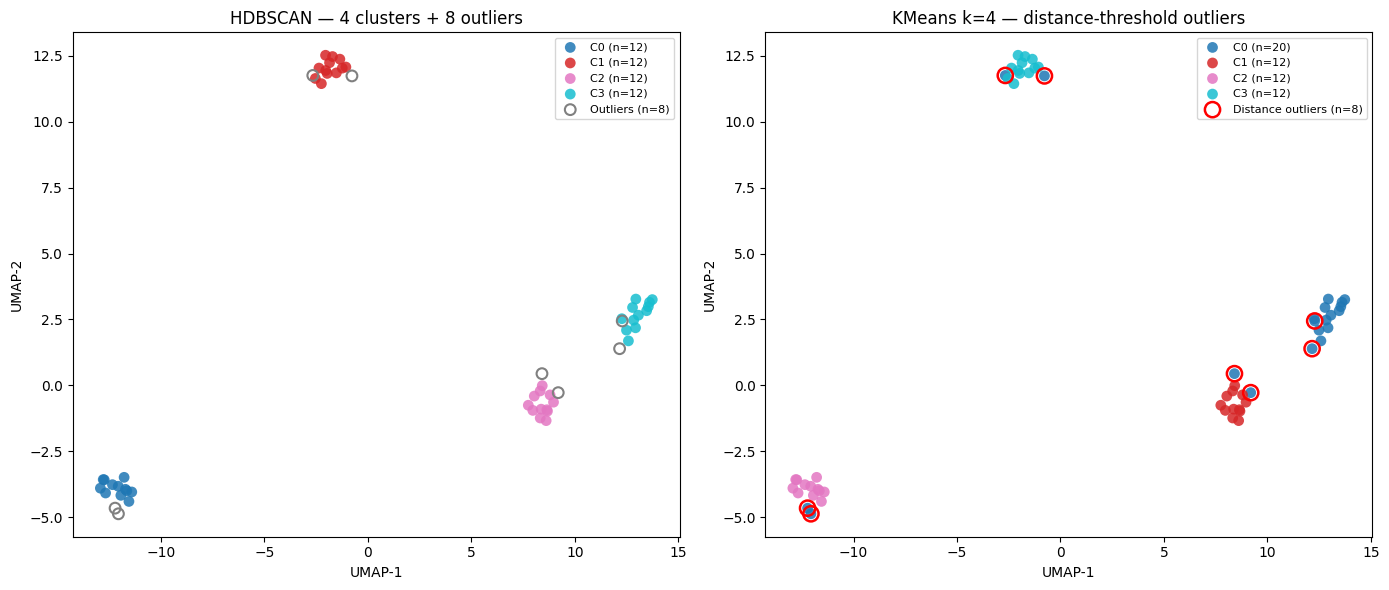

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- HDBSCAN panel ---
ax = axes[0]
cluster_ids = np.sort(np.unique(labels_hdb[labels_hdb >= 0]))
palette = plt.cm.tab10(np.linspace(0, 1, max(len(cluster_ids), 1)))
for color, cid in zip(palette, cluster_ids):
    mask = labels_hdb == cid
    ax.scatter(coords[mask, 0], coords[mask, 1],
               s=60, color=color, label=f"C{cid} (n={int(mask.sum())})",
               alpha=0.85, edgecolor="none")
# Noise: gray, hollow
noise_mask = labels_hdb == -1
if noise_mask.any():
    ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
               s=60, facecolors="none", edgecolors="gray",
               linewidth=1.5, label=f"Outliers (n={int(noise_mask.sum())})")

ax.set_title(f"HDBSCAN — {n_clusters} clusters + {n_noise} outliers")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(loc="best", fontsize=8)

# --- KMeans panel ---
ax = axes[1]
for color, cid in zip(palette, sorted(set(labels_km.tolist()))):
    mask = labels_km == cid
    ax.scatter(coords[mask, 0], coords[mask, 1],
               s=60, color=color, label=f"C{cid} (n={int(mask.sum())})",
               alpha=0.85, edgecolor="none")
if is_outlier_km.any():
    ax.scatter(coords[is_outlier_km, 0], coords[is_outlier_km, 1],
               s=120, facecolors="none", edgecolors="red",
               linewidth=1.8, label=f"Distance outliers (n={int(is_outlier_km.sum())})")

ax.set_title(f"KMeans k={k} — distance-threshold outliers")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

## 8. How the plugin wires this up

The plugin's clustering stage is `run_clustering` in `__init__.py`. Condensed signature:

```python
def run_clustering(
    dataset: fo.Dataset,
    n_clusters: int = 0,
    outlier_std_factor: float = OUTLIER_STD_FACTOR,
) -> tuple:  # (n_samples, n_clusters, n_noise)
    ...
    if n_clusters > 0:
        # KMeans branch: fixed k, distance-threshold outliers, confidence = 1.0
        ...
    else:
        # HDBSCAN branch: density-based, native noise, confidence = probabilities_
        ...
    # Shared tail: UMAP 2D + write cluster_id / centroid_distance / is_outlier /
    # cluster_confidence / umap_x / umap_y to every sample.
```

Inside the **AnalyzeCoverage** operator:
- The **Number of Clusters** input defaults to `0` (HDBSCAN). Set it to a positive integer to switch to KMeans.
- The **Outlier Threshold** input is labeled "(KMeans only)" — it has no effect under HDBSCAN.
- The stage-2 progress label reads *"Clustered X samples into Y groups (Z outliers)"* so users see at a glance which algorithm ran and how many outliers surfaced.

And in **CoveragePanel**, noise points are split into a dedicated *"Outliers (N)"* trace using `symbol="circle-open"` with a gray outline — matching the matplotlib rendering above.